# VISTA Exploratory Checklist

This notebook demonstrates the VISTA exploratory checklist — a simple six-check evaluation
for MCDA ranking methods. We apply it to Fuzzy TOPSIS and show how the protocol
can reveal method strengths and weaknesses at a glance. The six checks are as follows:

| # | Check | What it verifies |
|---|-------|------------------|
| 1 | **Dominance relation** | No red in dominating cone, no green in dominated cone |
| 2 | **Self-indifference** | Reference point vs. itself → Indifferent |
| 3 | **Diagonal preference** | At most 1 transition along the main diagonal |
| 4 | **Radial preference** | At most 1 transition along any ray from reference |
| 5 | **Preference ratio** | Balanced Better/Worse ratio (~1:1 at midpoint) |
| 6 | **Third alternative stability** | VISTA doesn't change much when a third alternative is added |

In [2]:
from mcda_vista.protocol import run_protocol, plot_protocol_report
from mcda_vista.fuzzy_utils import fuzzy_topsis
from mcda_vista.plotting import plot_vista_comparison

## 1. Run the protocol on Fuzzy TOPSIS (crisp baseline)

With `spread=0.0`, Fuzzy TOPSIS behaves like standard TOPSIS (degenerate triangular numbers).

In [3]:
report_crisp = run_protocol(
    fuzzy_topsis,
    resolution=101,
    spread=0.0,
    delta=0.10,
)
print(report_crisp.summary())

VISTA (fuzzy_topsis): 100%|████████████████████████████████████████████████████| 10201/10201 [00:02<00:00, 3675.55pt/s]

VISTA Protocol Report: fuzzy_topsis
  ✓ PASS  Dominance relation: No violations (2500 dominating, 2500 dominated points).
  ✗? FAIL  Self-indifference: Reference point is Error — likely a numerical issue (nearest grid point at distance 0.0000).
  ✓ PASS  Diagonal preference change: Upper-right: 1 transition(s), lower-left: 1 transition(s).
  ✓ PASS  Radial preference change: All 36 rays have at most 1 transition.
  ● IMBALANCED  Preference ratio: Imbalanced (56.3% worse, 37.5% better than reference).
  ✗ FAIL  Third alternative stability: Max change 10.4% > 5%. Changes: [0.5, 0.5]: 0.0%, [0.25, 0.5]: 2.7%, [0.5, 0.75]: 8.8%, [0.25, 0.25]: 5.4%, [0.25, 0.75]: 10.4%.


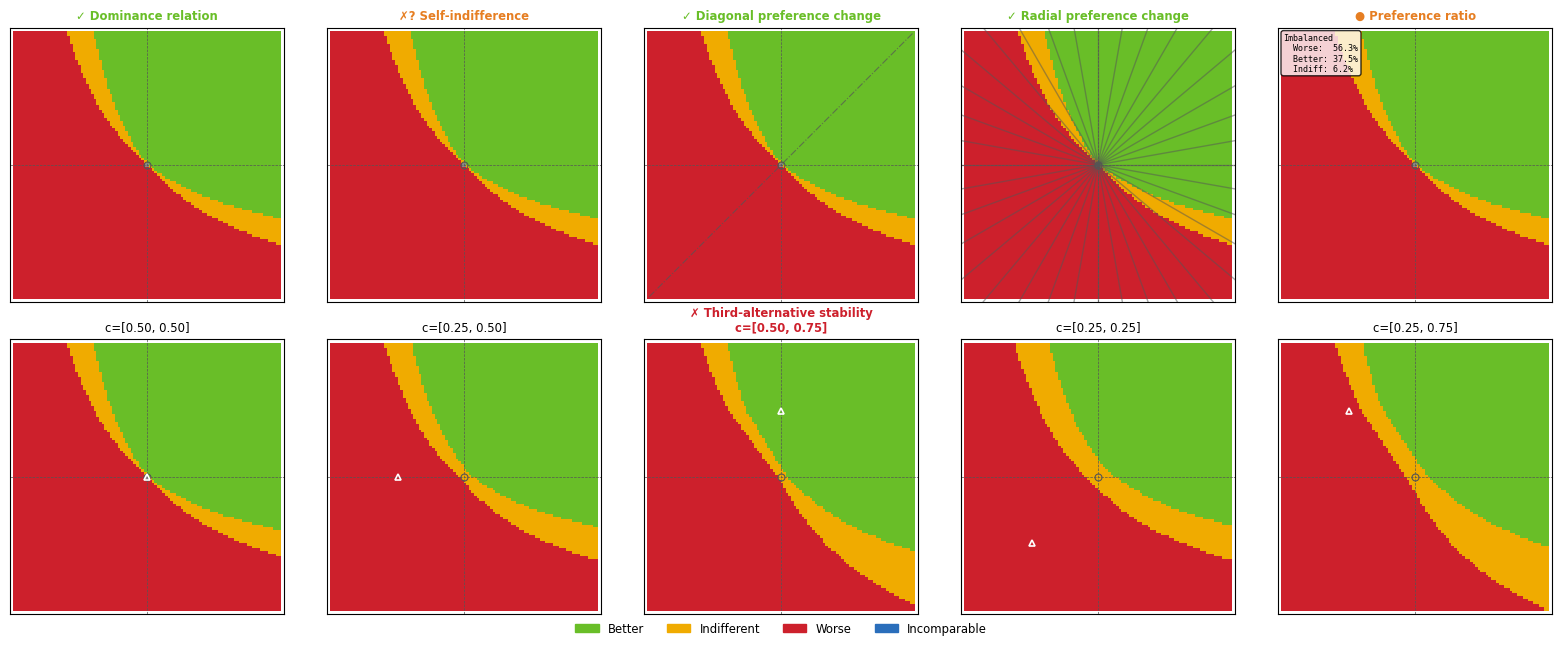

In [4]:
fig = plot_protocol_report(report_crisp, point_size=5)
fig.savefig("protocol_fuzzy_topsis_crisp.png", dpi=150, bbox_inches="tight")

## 2. Run the protocol with fuzzification (spread=0.10)

Adding fuzzification changes the decision boundaries. Let's see how the protocol results differ.

In [5]:
report_fuzzy = run_protocol(
    fuzzy_topsis,
    resolution=101,
    spread=0.10,
    delta=0.10,
)
print(report_fuzzy.summary())

VISTA (fuzzy_topsis): 100%|████████████████████████████████████████████████████| 10201/10201 [00:02<00:00, 3559.44pt/s]

VISTA Protocol Report: fuzzy_topsis
  ✓ PASS  Dominance relation: No violations (2500 dominating, 2500 dominated points).
  ✗? FAIL  Self-indifference: Reference point is Error — likely a numerical issue (nearest grid point at distance 0.0000).
  ✓ PASS  Diagonal preference change: Upper-right: 1 transition(s), lower-left: 1 transition(s).
  ✓ PASS  Radial preference change: All 36 rays have at most 1 transition.
  ● IMBALANCED  Preference ratio: Imbalanced (55.0% worse, 38.4% better than reference).
  ✗ FAIL  Third alternative stability: Max change 9.8% > 5%. Changes: [0.5, 0.5]: 0.0%, [0.25, 0.5]: 2.8%, [0.5, 0.75]: 8.1%, [0.25, 0.25]: 5.6%, [0.25, 0.75]: 9.8%.


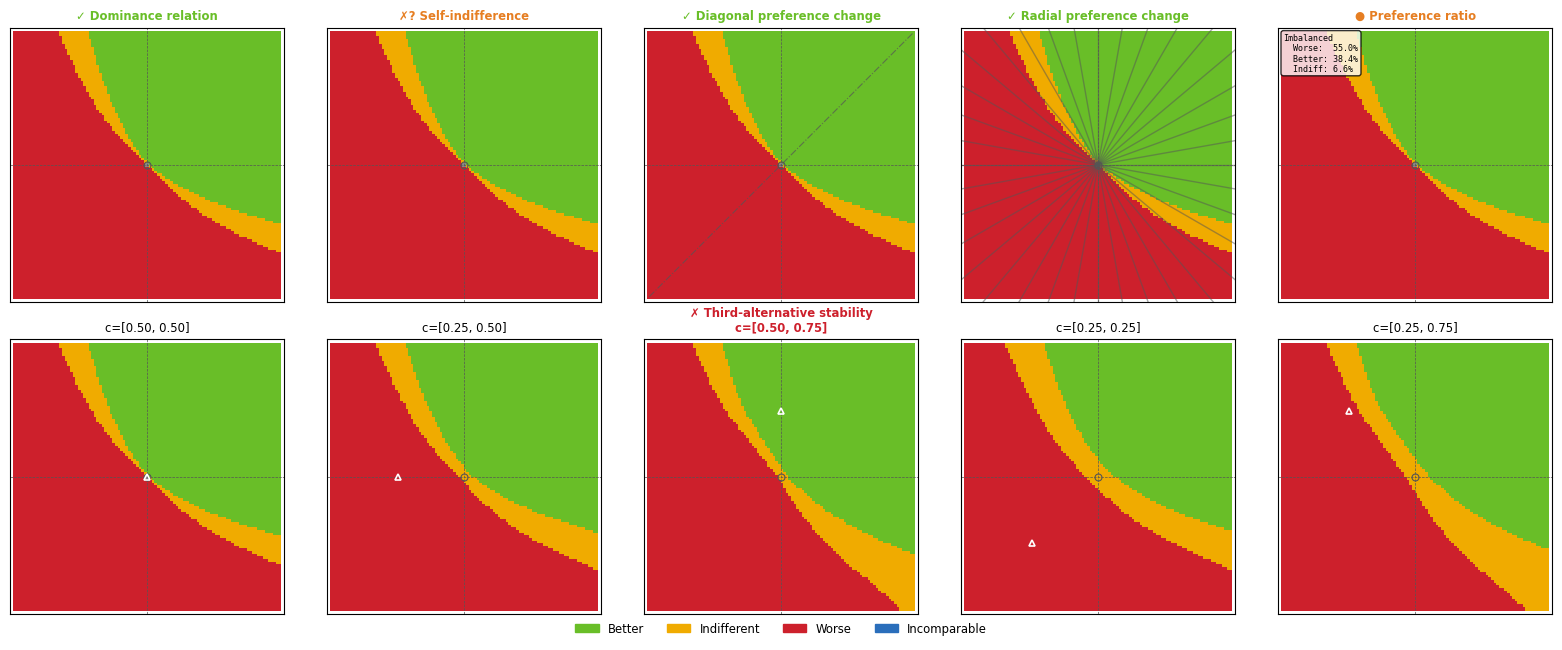

In [6]:
fig = plot_protocol_report(report_fuzzy, point_size=5)
fig.savefig("protocol_fuzzy_topsis_spread01.png", dpi=150, bbox_inches="tight")

## 3. Compare baselines side by side

Use `plot_vista_comparison` to see the crisp and fuzzy baselines together.

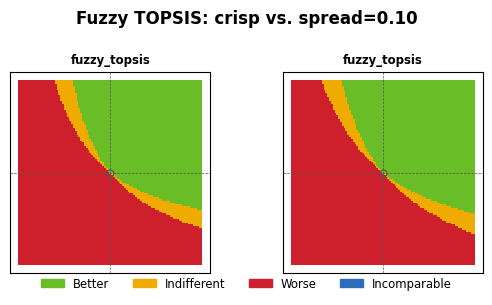

In [7]:
fig = plot_vista_comparison(
    [report_crisp.baseline, report_fuzzy.baseline],
    title="Fuzzy TOPSIS: crisp vs. spread=0.10",
)

## 4. Inspecting individual checks

Each check result contains detailed metrics in its `detail` dictionary.

In [8]:
for check in report_fuzzy.checks:
    if check.passed is True:
        status = "PASS"
    elif check.passed is False:
        err = " (numerical error)" if check.detail.get("is_numerical_error") else ""
        status = f"FAIL{err}"
    else:
        balanced = check.detail.get("balanced")
        status = "BALANCED" if balanced else ("IMBALANCED" if balanced is False else "N/A")
    print(f"[{status}] {check.name}")
    print(f"  {check.message}")
    for k, v in check.detail.items():
        if k not in ("diagonal_relations", "ray_transitions"):
            print(f"  {k}: {v}")
    print()

[PASS] Dominance relation
  No violations (2500 dominating, 2500 dominated points).
  worse_in_dominating: 0
  better_in_dominated: 0
  dominating_total: 2500
  dominated_total: 2500

[FAIL (numerical error)] Self-indifference
  Reference point is Error — likely a numerical issue (nearest grid point at distance 0.0000).
  nearest_relation: ERROR
  nearest_point: [0.5, 0.5]
  distance: 0.0
  is_numerical_error: True

[PASS] Diagonal preference change
  Upper-right: 1 transition(s), lower-left: 1 transition(s).
  upper_transitions: 1
  lower_transitions: 1
  ref_index: 50

[PASS] Radial preference change
  All 36 rays have at most 1 transition.
  n_rays: 36
  violating_angles_deg: []
  worst_transitions: 1

[IMBALANCED] Preference ratio
  Imbalanced (55.0% worse, 38.4% better than reference).
  ratio: 0.6975418596366227
  balanced: False
  counts: {'ERROR': 1, 'WORSE': 5614, 'INDIFFERENT': 670, 'BETTER': 3916, 'INCOMPARABLE': 0}
  percentages: {'ERROR': 0.009802960494069209, 'WORSE': 55.

## 5. Custom protocol: weight sensitivity

The protocol optionally re-runs checks 1–5 with different weight vectors.
This is useful when the decision maker expects large differences in weights.

In [9]:
report_weights = run_protocol(
    fuzzy_topsis,
    resolution=51,
    extra_weights=[[0.25, 0.75], [0.75, 0.25]],
    spread=0.10,
    delta=0.10,
)
print(report_weights.summary())

VISTA (fuzzy_topsis): 100%|██████████████████████████████████████████████████████| 2601/2601 [00:00<00:00, 4276.57pt/s]

VISTA Protocol Report: fuzzy_topsis
  ✓ PASS  Dominance relation: No violations (625 dominating, 625 dominated points).
  ✗? FAIL  Self-indifference: Reference point is Error — likely a numerical issue (nearest grid point at distance 0.0000).
  ✓ PASS  Diagonal preference change: Upper-right: 1 transition(s), lower-left: 1 transition(s).
  ✓ PASS  Radial preference change: All 36 rays have at most 1 transition.
  ● IMBALANCED  Preference ratio: Imbalanced (54.9% worse, 38.4% better than reference).
  ✗ FAIL  Third alternative stability: Max change 9.6% > 5%. Changes: [0.5, 0.5]: 0.0%, [0.25, 0.5]: 2.8%, [0.5, 0.75]: 8.0%, [0.25, 0.25]: 5.3%, [0.25, 0.75]: 9.6%.

Weight sensitivity:
  weights=[0.25, 0.75]: 2/5 checks passed
  weights=[0.75, 0.25]: 2/5 checks passed


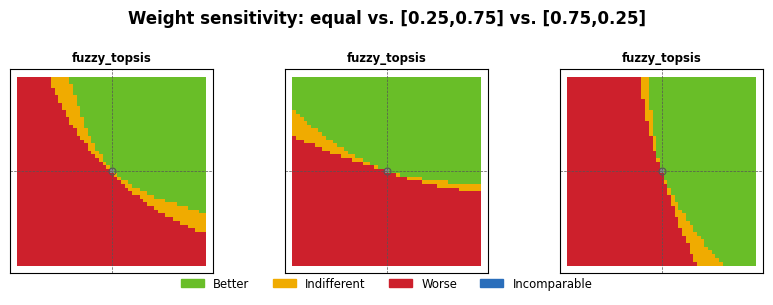

In [10]:
weight_vistas = [ws[1] for ws in report_weights.weight_sensitivity]
fig = plot_vista_comparison(
    [report_weights.baseline] + weight_vistas,
    title="Weight sensitivity: equal vs. [0.25,0.75] vs. [0.75,0.25]",
    point_size=5
)

## 7. Using the protocol with any method

You can plug in any VISTA-compatible method with a registered name or a custom callable.

VISTA (saw): 100%|███████████████████████████████████████████████████████████████| 2601/2601 [00:00<00:00, 5529.87pt/s]


VISTA Protocol Report: saw
  ✓ PASS  Dominance relation: No violations (625 dominating, 625 dominated points).
  ✓ PASS  Self-indifference: Reference point is Indifferent (nearest grid point at distance 0.0000).
  ✓ PASS  Diagonal preference change: Upper-right: 1 transition(s), lower-left: 1 transition(s).
  ✓ PASS  Radial preference change: All 36 rays have at most 1 transition.
  ● IMBALANCED  Preference ratio: Imbalanced (54.8% worse, 35.4% better than reference).
  ✗ FAIL  Third alternative stability: Max change 8.2% > 5%. Changes: [0.5, 0.5]: 0.0%, [0.25, 0.5]: 0.0%, [0.5, 0.75]: 8.2%, [0.25, 0.25]: 0.0%, [0.25, 0.75]: 8.2%.


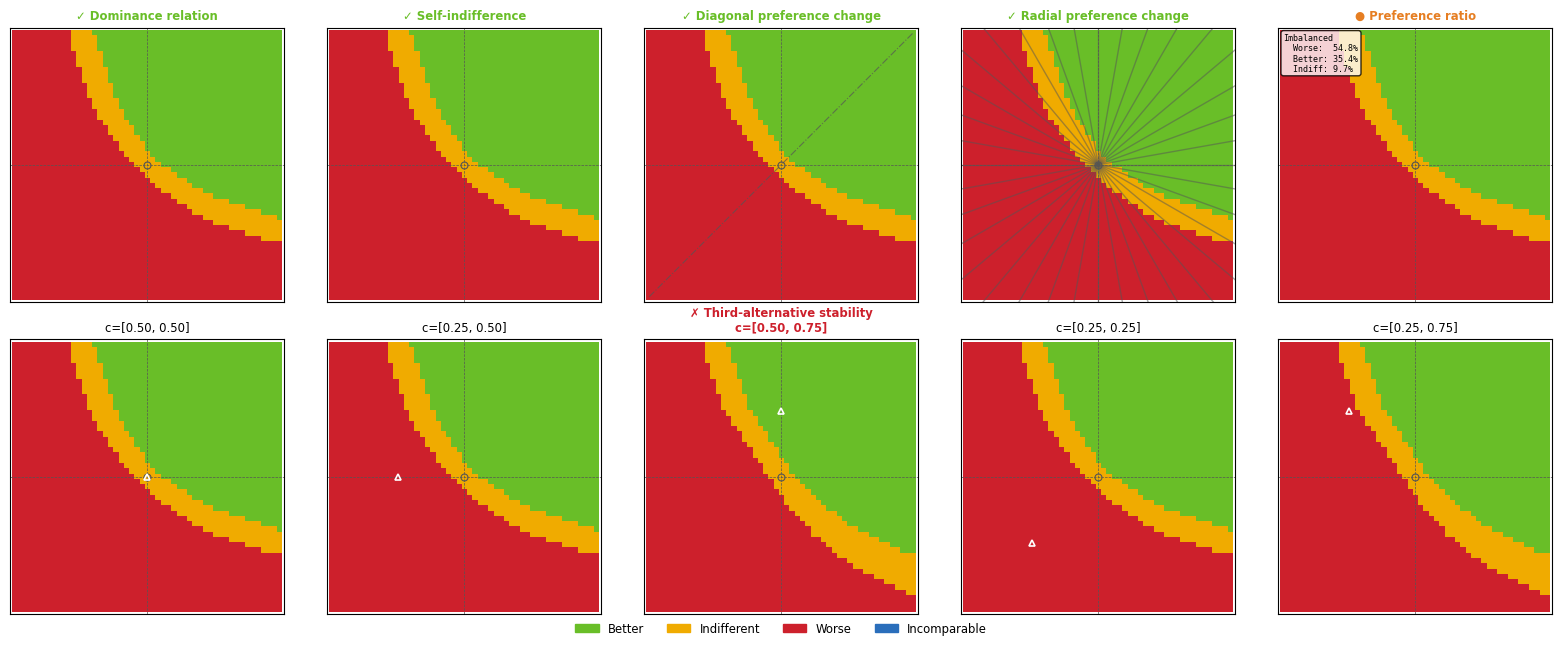

In [15]:
# Using registered method names
report_saw = run_protocol("saw", resolution=51, delta=0.10)
print(report_saw.summary())
fig = plot_protocol_report(report_saw, point_size=15)

VISTA (etopsis): 100%|███████████████████████████████████████████████████████████| 2601/2601 [00:00<00:00, 3226.19pt/s]


VISTA Protocol Report: etopsis
  ✓ PASS  Dominance relation: No violations (625 dominating, 625 dominated points).
  ✓ PASS  Self-indifference: Reference point is Indifferent (nearest grid point at distance 0.0000).
  ✓ PASS  Diagonal preference change: Upper-right: 1 transition(s), lower-left: 1 transition(s).
  ✓ PASS  Radial preference change: All 36 rays have at most 1 transition.
  ● BALANCED  Preference ratio: Balanced (34.2% worse, 34.2% better than reference).
  ✓ PASS  Third alternative stability: Max change 0.0% ≤ 5%. Changes: [0.5, 0.5]: 0.0%, [0.25, 0.5]: 0.0%, [0.5, 0.75]: 0.0%, [0.25, 0.25]: 0.0%, [0.25, 0.75]: 0.0%.


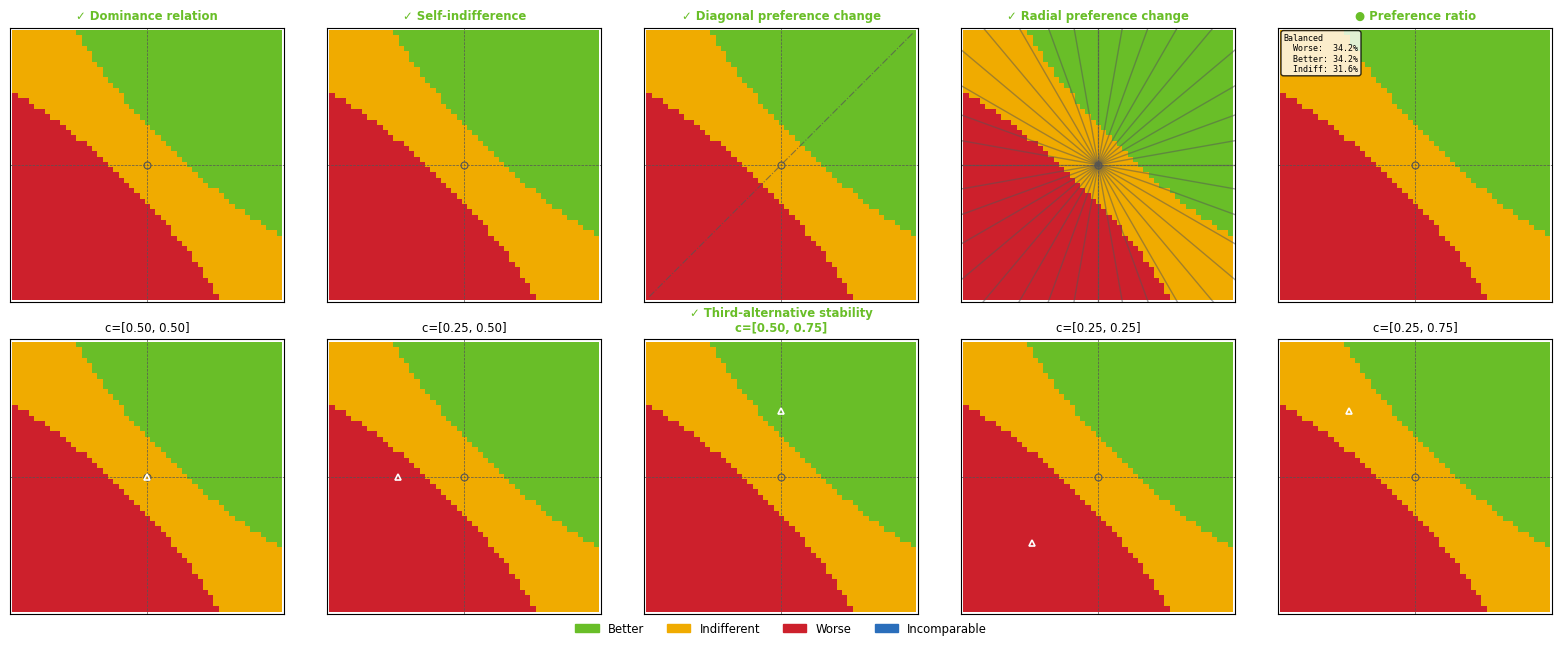

In [16]:
report_etopsis = run_protocol("etopsis", resolution=51, delta=0.10)
print(report_etopsis.summary())
fig = plot_protocol_report(report_etopsis, point_size=15)